## Cell 1 — Imports

In [1]:
import os
import gc
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Cell 2 — Reproducibility

In [2]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Seed:", SEED)

Seed: 42


## Cell 3 — Mount Drive

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Cell 4 — Dataset Paths



In [4]:
DRIVE_DATASET_DIR = Path(
    "/content/drive/MyDrive/Cellula/EyeDisease/Data/dataset_splits_v2"
)

LOCAL_DATASET_DIR = Path(
    "/content/dataset_splits_v2"
)

if not DRIVE_DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DRIVE_DATASET_DIR}"
    )

if not LOCAL_DATASET_DIR.exists():
    print("Copying dataset to local Colab storage...")
    shutil.copytree(
        DRIVE_DATASET_DIR,
        LOCAL_DATASET_DIR
    )
    print("Copy completed.")
else:
    print("Local dataset already exists.")

Copying dataset to local Colab storage...
Copy completed.


## Cell 5 — Train / Validation / Test

In [5]:
TRAIN_DIR = LOCAL_DATASET_DIR / "train"
VAL_DIR = LOCAL_DATASET_DIR / "val"
TEST_DIR = LOCAL_DATASET_DIR / "test"

for directory in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    if not directory.exists():
        raise FileNotFoundError(
            f"Missing directory: {directory}"
        )

print("TRAIN:", TRAIN_DIR)
print("VAL  :", VAL_DIR)
print("TEST :", TEST_DIR)

TRAIN: /content/dataset_splits_v2/train
VAL  : /content/dataset_splits_v2/val
TEST : /content/dataset_splits_v2/test


## Cell 6 — Configuration

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

MODEL1_EPOCHS_STAGE1 = 10
MODEL1_EPOCHS_STAGE2 = 6

MODEL2_EPOCHS_STAGE1 = 10
MODEL2_EPOCHS_STAGE2 = 6

LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-5

NUM_ORIGINAL_CLASSES = 8
NUM_MODEL1_CLASSES = 5
NUM_MODEL2_CLASSES = 4

## Cell 7 — Original Classes



In [7]:
ORIGINAL_CLASSES = [
    "AMD",
    "Cataract",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Hypertension",
    "Myopia",
    "Normal",
    "Others"
]

print("Original classes:")

for i, name in enumerate(ORIGINAL_CLASSES):
    print(i, "->", name)

Original classes:
0 -> AMD
1 -> Cataract
2 -> Diabetic Retinopathy
3 -> Glaucoma
4 -> Hypertension
5 -> Myopia
6 -> Normal
7 -> Others


## Cell 8 — Verify Folder Names

In [8]:
folder_classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

print("Dataset folders:")
print(folder_classes)

print("\nExpected classes:")
print(sorted(ORIGINAL_CLASSES))

if folder_classes != sorted(ORIGINAL_CLASSES):
    raise ValueError(
        "Dataset folder names do not match ORIGINAL_CLASSES"
    )

print("\nClass structure verified.")

Dataset folders:
['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']

Expected classes:
['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']

Class structure verified.


## Cell 9 — Count Images

In [9]:
def count_images(directory):

    counts = {}

    for class_name in ORIGINAL_CLASSES:

        class_dir = directory / class_name

        if not class_dir.exists():
            counts[class_name] = 0
            continue

        counts[class_name] = sum(
            1
            for file in class_dir.iterdir()
            if file.is_file()
        )

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

dataset_counts = pd.DataFrame({
    "Class": ORIGINAL_CLASSES,
    "Train": [train_counts[c] for c in ORIGINAL_CLASSES],
    "Validation": [val_counts[c] for c in ORIGINAL_CLASSES],
    "Test": [test_counts[c] for c in ORIGINAL_CLASSES]
})

dataset_counts

,Class,Train,Validation,Test
0,AMD,1000,41,41
1,Cataract,1000,51,51
2,Diabetic Retinopathy,2800,617,617
3,Glaucoma,1500,139,140
4,Hypertension,500,13,13
5,Myopia,1000,44,44
6,Normal,3000,705,705
7,Others,1500,166,165


## Cell 10 — Hierarchical Mapping



In [10]:
MINOR_CLASSES = [
    "Cataract",
    "AMD",
    "Hypertension",
    "Myopia"
]

MODEL1_CLASSES = [
    "Normal",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Others",
    "Minor_Diseases"
]

MODEL2_CLASSES = [
    "Cataract",
    "AMD",
    "Hypertension",
    "Myopia"
]

hierarchical_mapping = {

    "Normal": "Normal",

    "Diabetic Retinopathy":
        "Diabetic Retinopathy",

    "Glaucoma":
        "Glaucoma",

    "Others":
        "Others",

    "Cataract":
        "Minor_Diseases",

    "AMD":
        "Minor_Diseases",

    "Hypertension":
        "Minor_Diseases",

    "Myopia":
        "Minor_Diseases"
}

mapping_df = pd.DataFrame(
    list(hierarchical_mapping.items()),
    columns=[
        "Original_Label",
        "Model1_Label"
    ]
)

mapping_df

,Original_Label,Model1_Label
0,Normal,Normal
1,Diabetic Retinopathy,Diabetic Retinopathy
2,Glaucoma,Glaucoma
3,Others,Others
4,Cataract,Minor_Diseases
5,AMD,Minor_Diseases
6,Hypertension,Minor_Diseases
7,Myopia,Minor_Diseases


## Cell 11 — Load Original Datasets



In [11]:
train_raw = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_raw = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_raw = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

dataset_class_names = train_raw.class_names

print(dataset_class_names)

Found 12300 files belonging to 8 classes.
Found 1776 files belonging to 8 classes.
Found 1776 files belonging to 8 classes.
['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


## Cell 12 — Verify Class Order

In [12]:
if dataset_class_names != ORIGINAL_CLASSES:
    raise ValueError(
        f"Unexpected class order.\n"
        f"Expected: {ORIGINAL_CLASSES}\n"
        f"Found: {dataset_class_names}"
    )

print("Class order verified.")

Class order verified.


## Cell 13 — Original Label → Model 1 Label



In [13]:
original_to_model1 = {
    0: 4,  # AMD -> Minor_Diseases
    1: 4,  # Cataract -> Minor_Diseases
    2: 1,  # DR -> DR
    3: 2,  # Glaucoma -> Glaucoma
    4: 4,  # Hypertension -> Minor_Diseases
    5: 4,  # Myopia -> Minor_Diseases
    6: 0,  # Normal -> Normal
    7: 3   # Others -> Others
}

print(original_to_model1)

{0: 4, 1: 4, 2: 1, 3: 2, 4: 4, 5: 4, 6: 0, 7: 3}


## Cell 14 — Model 1 Dataset

In [14]:
def convert_to_model1(images, labels):

    new_labels = tf.gather(
        tf.constant([
            original_to_model1[i]
            for i in range(8)
        ]),
        labels
    )

    return images, new_labels


train_model1 = train_raw.map(
    convert_to_model1,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_model1 = val_raw.map(
    convert_to_model1,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_model1 = test_raw.map(
    convert_to_model1,
    num_parallel_calls=tf.data.AUTOTUNE
)

## Cell 15 — Model 1 Distribution

In [15]:
def get_dataset_label_counts(dataset, num_classes):

    counts = np.zeros(num_classes, dtype=int)

    for _, labels in dataset:

        labels = labels.numpy()

        for label in labels:
            counts[label] += 1

    return counts


model1_train_counts = get_dataset_label_counts(
    train_model1,
    NUM_MODEL1_CLASSES
)

model1_val_counts = get_dataset_label_counts(
    val_model1,
    NUM_MODEL1_CLASSES
)

model1_test_counts = get_dataset_label_counts(
    test_model1,
    NUM_MODEL1_CLASSES
)

model1_distribution = pd.DataFrame({
    "Class": MODEL1_CLASSES,
    "Train": model1_train_counts,
    "Validation": model1_val_counts,
    "Test": model1_test_counts
})

model1_distribution

,Class,Train,Validation,Test
0,Normal,3000,705,705
1,Diabetic Retinopathy,2800,617,617
2,Glaucoma,1500,139,140
3,Others,1500,166,165
4,Minor_Diseases,3500,149,149


## Cell 16 — Model 2 Dataset



In [16]:
MINOR_ORIGINAL_IDS = tf.constant([
    0,  # AMD
    1,  # Cataract
    4,  # Hypertension
    5   # Myopia
], dtype=tf.int32)

In [17]:
def filter_minor(images, labels):

    mask = tf.reduce_any(
        tf.equal(
            tf.expand_dims(labels, axis=1),
            MINOR_ORIGINAL_IDS
        ),
        axis=1
    )

    return (
        tf.boolean_mask(images, mask),
        tf.boolean_mask(labels, mask)
    )

## Cell 17 — Convert Model 2 Labels

In [18]:
original_to_model2 = {
    0: 1,  # AMD
    1: 0,  # Cataract
    4: 2,  # Hypertension
    5: 3   # Myopia
}


def convert_to_model2(images, labels):

    images, labels = filter_minor(
        images,
        labels
    )

    lookup = tf.constant([
        1,  # AMD
        0,  # Cataract
        0,  # unused
        0,  # unused
        2,  # Hypertension
        3,  # Myopia
        0,  # unused
        0   # unused
    ])

    new_labels = tf.gather(
        lookup,
        labels
    )

    return images, new_labels

## Cell 18 — Create Model 2 Dataset

In [19]:
train_model2 = train_raw.map(
    convert_to_model2,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_model2 = val_raw.map(
    convert_to_model2,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_model2 = test_raw.map(
    convert_to_model2,
    num_parallel_calls=tf.data.AUTOTUNE
)

## Cell 19 — Model 2 Distribution

In [20]:
model2_train_counts = get_dataset_label_counts(
    train_model2,
    NUM_MODEL2_CLASSES
)

model2_val_counts = get_dataset_label_counts(
    val_model2,
    NUM_MODEL2_CLASSES
)

model2_test_counts = get_dataset_label_counts(
    test_model2,
    NUM_MODEL2_CLASSES
)

model2_distribution = pd.DataFrame({
    "Class": MODEL2_CLASSES,
    "Train": model2_train_counts,
    "Validation": model2_val_counts,
    "Test": model2_test_counts
})

model2_distribution

,Class,Train,Validation,Test
0,Cataract,1000,51,51
1,AMD,1000,41,41
2,Hypertension,500,13,13
3,Myopia,1000,44,44


## Cell 21 — ResNet Preprocessing

In [21]:
def preprocess_resnet_train(images, labels):

    images = tf.cast(
        images,
        tf.float32
    )

    images = preprocess_input(images)

    return images, labels


def preprocess_resnet_eval(images, labels):

    images = tf.cast(
        images,
        tf.float32
    )

    images = preprocess_input(images)

    return images, labels

## Cell 22 — Final Model 1 Pipeline

In [22]:
train_model1_final = train_model1.map(
    preprocess_resnet_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_model1_final = val_model1.map(
    preprocess_resnet_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_model1_final = test_model1.map(
    preprocess_resnet_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_model1_final = train_model1_final.prefetch(
    tf.data.AUTOTUNE
)

val_model1_final = val_model1_final.prefetch(
    tf.data.AUTOTUNE
)

test_model1_final = test_model1_final.prefetch(
    tf.data.AUTOTUNE
)

## Cell 23 — Final Model 2 Pipeline

In [23]:
train_model2_final = train_model2.map(
    preprocess_resnet_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_model2_final = val_model2.map(
    preprocess_resnet_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_model2_final = test_model2.map(
    preprocess_resnet_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_model2_final = train_model2_final.prefetch(
    tf.data.AUTOTUNE
)

val_model2_final = val_model2_final.prefetch(
    tf.data.AUTOTUNE
)

test_model2_final = test_model2_final.prefetch(
    tf.data.AUTOTUNE
)

## Cell 24 — Model 1 Class Weights



In [24]:
original_counts = {
    "AMD": 274,
    "Cataract": 340,
    "Diabetic Retinopathy": 4113,
    "Glaucoma": 930,
    "Hypertension": 88,
    "Myopia": 294,
    "Normal": 4698,
    "Others": 1102
}

In [25]:
model1_original_counts = {
    "Normal": original_counts["Normal"],
    "Diabetic Retinopathy": original_counts["Diabetic Retinopathy"],
    "Glaucoma": original_counts["Glaucoma"],
    "Others": original_counts["Others"],
    "Minor_Diseases": (
        original_counts["Cataract"]
        + original_counts["AMD"]
        + original_counts["Hypertension"]
        + original_counts["Myopia"]
    )
}

total_model1 = sum(
    model1_original_counts.values()
)

model1_weights = {}

for i, class_name in enumerate(MODEL1_CLASSES):

    count = model1_original_counts[class_name]

    weight = np.sqrt(
        total_model1 /
        (
            NUM_MODEL1_CLASSES *
            count
        )
    )

    model1_weights[i] = weight


mean_weight = np.mean(
    list(model1_weights.values())
)

for i in model1_weights:
    model1_weights[i] /= mean_weight
    model1_weights[i] = np.clip(
        model1_weights[i],
        0.5,
        3.0
    )

print(model1_weights)

{0: np.float64(0.5845964553375768), 1: np.float64(0.6247889344086353), 2: np.float64(1.3139269170266812), 3: np.float64(1.2070406233745934), 4: np.float64(1.2696470698525133)}


## Cell 25 — Model 2 Class Weights

In [26]:
model2_original_counts = {
    "Cataract": original_counts["Cataract"],
    "AMD": original_counts["AMD"],
    "Hypertension": original_counts["Hypertension"],
    "Myopia": original_counts["Myopia"]
}

total_model2 = sum(
    model2_original_counts.values()
)

model2_weights = {}

for i, class_name in enumerate(MODEL2_CLASSES):

    count = model2_original_counts[class_name]

    weight = np.sqrt(
        total_model2 /
        (
            NUM_MODEL2_CLASSES *
            count
        )
    )

    model2_weights[i] = weight


mean_weight = np.mean(
    list(model2_weights.values())
)

for i in model2_weights:
    model2_weights[i] /= mean_weight
    model2_weights[i] = np.clip(
        model2_weights[i],
        0.5,
        3.0
    )

print(model2_weights)

{0: np.float64(0.7759533475937384), 1: np.float64(0.8643702048824479), 2: np.float64(1.5252243620286279), 3: np.float64(0.8344520854951858)}


## Cell 26 — ResNet50 Classifier Builder

In [27]:
def build_resnet_classifier(
    num_classes,
    name
):

    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        )
    )

    base_model.trainable = False

    inputs = layers.Input(
        shape=(
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        )
    )

    x = base_model(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs,
        outputs,
        name=name
    )

    return model, base_model

## Cell 27 — Create Model 1

In [ ]:
model1, model1_base = build_resnet_classifier(
    NUM_MODEL1_CLASSES,
    "hierarchical_model1_resnet50"
)

model1.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "hierarchical_model1_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,137,221 (92.08 MB)

 Trainable params: 545,413 (2.08 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Cell 28 — Compile Model 1

In [ ]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_STAGE1
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Cell 29 — Model 1 Save Paths

In [ ]:
MODEL1_DIR = Path(
    "/content/drive/MyDrive/Cellula/EyeDisease/"
    "models/hierarchical/model1"
)

MODEL1_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL1_BEST = MODEL1_DIR / "model1_best.keras"
MODEL1_FINAL = MODEL1_DIR / "model1_final.keras"
MODEL1_HISTORY = MODEL1_DIR / "history.json"
MODEL1_CONFIG = MODEL1_DIR / "config.json"

## Cell 30 — Model 1 Callbacks



In [ ]:
model1_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL1_BEST),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

## Cell 31 — Train Model 1 Stage 1

In [ ]:
history1_stage1 = model1.fit(
    train_model1_final,
    validation_data=val_model1_final,
    epochs=MODEL1_EPOCHS_STAGE1,
    class_weight=model1_weights,
    callbacks=model1_callbacks
)

Epoch 1/10
769/769 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.4442 - loss: 1.4535
Epoch 1: val_loss improved from None to 1.13387, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras
769/769 ━━━━━━━━━━━━━━━━━━━━ 386s 477ms/step - accuracy: 0.4883 - loss: 1.2182 - val_accuracy: 0.4313 - val_loss: 1.1339 - learning_rate: 0.0010
Epoch 2/10
768/769 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.5330 - loss: 0.9940
Epoch 2: val_loss improved from 1.13387 to 1.07374, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras
769/769 ━━━━━━━━━━━━━━━━━━━━ 359s 466ms/step - accuracy: 0.5379 - loss: 0.9845 - val_accuracy: 0.4561 - val_loss: 1.0737 - learn

## Cell 32 — Fine-Tune Model 1



In [ ]:
model1_base.trainable = True

for layer in model1_base.layers[:-30]:
    layer.trainable = False

model1.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_STAGE2
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Cell 33 — Model 1 Stage 2

In [ ]:
history1_stage2 = model1.fit(
    train_model1_final,
    validation_data=val_model1_final,
    epochs=MODEL1_EPOCHS_STAGE2,
    class_weight=model1_weights,
    callbacks=model1_callbacks
)

Epoch 1/6
769/769 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5983 - loss: 0.8394
Epoch 1: val_loss improved from 0.95167 to 0.93772, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras
769/769 ━━━━━━━━━━━━━━━━━━━━ 390s 477ms/step - accuracy: 0.6093 - loss: 0.8122 - val_accuracy: 0.5366 - val_loss: 0.9377 - learning_rate: 1.0000e-05
Epoch 2/6
769/769 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.6267 - loss: 0.7632
Epoch 2: val_loss improved from 0.93772 to 0.92765, saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_best.keras
769/769 ━━━━━━━━━━━━━━━━━━━━ 382s 494ms/step - accuracy: 0.6324 - loss: 0.7498 - val_accuracy: 0.5315 - val_loss: 0.9276 - 

## Cell 34 — Save Model 1

In [ ]:
model1.save(
    MODEL1_FINAL
)

print("Model 1 saved:")
print(MODEL1_FINAL)

Model 1 saved:
/content/drive/MyDrive/Cellula/EyeDisease/models/hierarchical/model1/model1_final.keras


## Cell 35 — Evaluation Function

In [ ]:
def evaluate_model(
    model,
    dataset,
    class_names,
    title
):

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            np.argmax(
                predictions,
                axis=1
            )
        )

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"\n===== {title} =====")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print("Accuracy :", accuracy)
    print("Macro Precision:", precision)
    print("Macro Recall   :", recall)
    print("Macro F1       :", f1)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "confusion_matrix": cm
    }

## Cell 36 — Evaluate Model 1


===== Model 1 — 5-Class Test Evaluation =====
                      precision    recall  f1-score   support

              Normal     0.8920    0.4922    0.6344       705
Diabetic Retinopathy     0.9040    0.4733    0.6213       617
            Glaucoma     0.6078    0.6643    0.6348       140
              Others     0.1887    0.8485    0.3087       165
      Minor_Diseases     0.5680    0.6443    0.6038       149

            accuracy                         0.5450      1776
           macro avg     0.6321    0.6245    0.5606      1776
        weighted avg     0.7813    0.5450    0.5970      1776

Accuracy : 0.545045045045045
Macro Precision: 0.6321250671893868
Macro Recall   : 0.6245044289771197
Macro F1       : 0.560588357487189


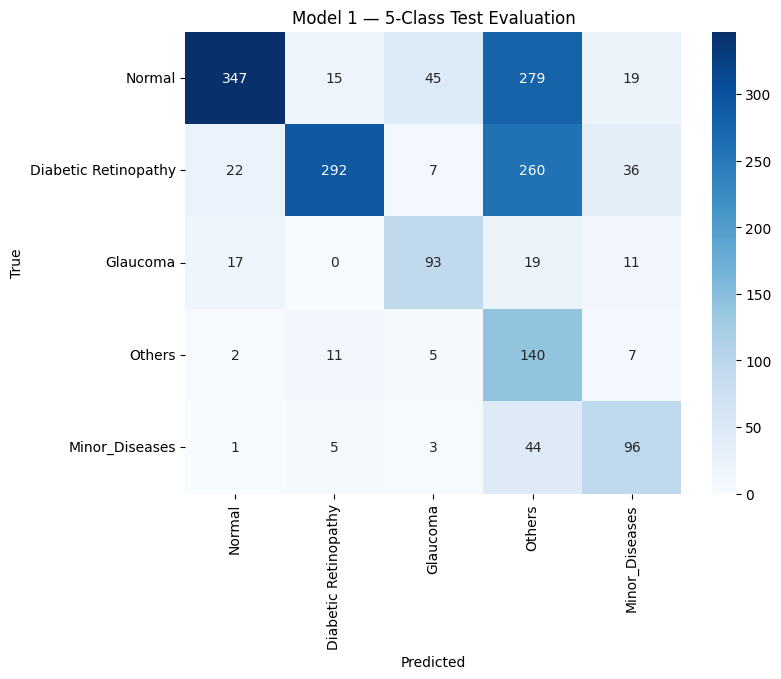

In [ ]:
model1_results = evaluate_model(
    model1,
    test_model1_final,
    MODEL1_CLASSES,
    "Model 1 — 5-Class Test Evaluation"
)

## Cell 37 — Build Model 2

In [38]:
model2, model2_base = build_resnet_classifier(
    NUM_MODEL2_CLASSES,
    "hierarchical_model2_resnet50"
)

model2.summary()

Model: "hierarchical_model2_resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,137,156 (92.08 MB)

 Trainable params: 545,348 (2.08 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Cell 38 — Compile Model 2

In [39]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_STAGE1
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Cell 39 — Model 2 Paths

In [40]:
MODEL2_DIR = Path(
    "/content/drive/MyDrive/Cellula/EyeDisease/"
    "models/hierarchical/model2"
)

MODEL2_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL2_BEST = MODEL2_DIR / "model2_best.keras"
MODEL2_FINAL = MODEL2_DIR / "model2_final.keras"
MODEL2_HISTORY = MODEL2_DIR / "history.json"
MODEL2_CONFIG = MODEL2_DIR / "config.json"

## Cell 40 — Model 2 Callbacks

In [41]:
model2_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL2_BEST),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [43]:
model2, model2_base = build_resnet_classifier(
    NUM_MODEL2_CLASSES,
    "hierarchical_model2_resnet50"
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
# ==========================================
# Find the first batch that produces NaN
# ==========================================

model2, model2_base = build_resnet_classifier(
    NUM_MODEL2_CLASSES,
    "hierarchical_model2_resnet50"
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

for batch_idx, (images, labels) in enumerate(train_model2_final):

    # Check input
    if (
        tf.reduce_any(tf.math.is_nan(images)) or
        tf.reduce_any(tf.math.is_inf(images))
    ):
        print("❌ BAD INPUT BATCH:", batch_idx)
        break

    # Forward pass
    preds = model2(images, training=True)

    # Check predictions
    if (
        tf.reduce_any(tf.math.is_nan(preds)) or
        tf.reduce_any(tf.math.is_inf(preds))
    ):
        print("❌ BAD PREDICTION BATCH:", batch_idx)
        print("Labels:", labels.numpy())
        print("Image min:", tf.reduce_min(images).numpy())
        print("Image max:", tf.reduce_max(images).numpy())
        break

    # Calculate loss
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels, preds
    )
    loss = tf.reduce_mean(loss)

    if (
        tf.math.is_nan(loss) or
        tf.math.is_inf(loss)
    ):
        print("❌ BAD LOSS BATCH:", batch_idx)
        print("Labels:", labels.numpy())
        print("Loss:", loss.numpy())
        break

    # Train one batch
    result = model2.train_on_batch(images, labels)

    if not np.isfinite(result[0]):
        print("❌ NaN AFTER UPDATE — batch:", batch_idx)
        print("Result:", result)
        break

    if batch_idx % 50 == 0:
        print(
            f"Batch {batch_idx}: "
            f"loss={result[0]:.4f}, "
            f"acc={result[1]:.4f}"
        )

else:
    print("✅ All batches completed without NaN")

Batch 0: loss=5.4206, acc=0.0000
Batch 50: loss=2.4344, acc=0.2202


ValueError: Exception encountered when calling Conv2D.call().

[1mThe convolution operation resulted in an empty output. Output shape: (0, 112, 112, 64). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.[0m

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 230, 230, 3), dtype=float32)

## Cell 41 — Train Model 2 Stage 1

In [42]:
history2_stage1 = model2.fit(
    train_model2_final,
    validation_data=val_model2_final,
    epochs=MODEL2_EPOCHS_STAGE1,
    class_weight=model2_weights,
    callbacks=model2_callbacks
)

Epoch 1/10
426/769 ━━━━━━━━━━━━━━━━━━━━ 1:58 346ms/step - accuracy: 0.3166 - loss: nan

KeyboardInterrupt: 

## Cell 42 — Fine-Tune Model 2

In [ ]:
model2_base.trainable = True

for layer in model2_base.layers[:-30]:
    layer.trainable = False

model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_STAGE2
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Cell 43 — Train Model 2 Stage 2

In [ ]:
history2_stage2 = model2.fit(
    train_model2_final,
    validation_data=val_model2_final,
    epochs=MODEL2_EPOCHS_STAGE2,
    class_weight=model2_weights,
    callbacks=model2_callbacks
)

## Cell 44 — Save Model 2

In [ ]:
model2.save(
    MODEL2_FINAL
)

print("Model 2 saved:")
print(MODEL2_FINAL)

## Cell 45 — Model 2 Evaluation

In [ ]:
model2_results = evaluate_model(
    model2,
    test_model2_final,
    MODEL2_CLASSES,
    "Model 2 — 4-Class Test Evaluation"
)

## Cell 46 — Hierarchical Prediction Maps



In [ ]:
MODEL1_TO_ORIGINAL = {
    0: "Normal",
    1: "Diabetic Retinopathy",
    2: "Glaucoma",
    3: "Others",
    4: "Minor_Diseases"
}

MODEL2_TO_ORIGINAL = {
    0: "Cataract",
    1: "AMD",
    2: "Hypertension",
    3: "Myopia"
}

## Cell 47 — Complete Hierarchical Inference Function

In [ ]:
def hierarchical_predict(
    images,
    model1,
    model2
):

    model1_probs = model1.predict(
        images,
        verbose=0
    )

    model1_preds = np.argmax(
        model1_probs,
        axis=1
    )

    final_predictions = []

    minor_indices = []

    for i, pred in enumerate(model1_preds):

        if pred == 4:
            minor_indices.append(i)

            final_predictions.append(
                None
            )

        else:
            final_predictions.append(
                MODEL1_TO_ORIGINAL[pred]
            )

    if minor_indices:

        minor_images = tf.gather(
            images,
            minor_indices
        )

        model2_probs = model2.predict(
            minor_images,
            verbose=0
        )

        model2_preds = np.argmax(
            model2_probs,
            axis=1
        )

        for idx, model2_pred in zip(
            minor_indices,
            model2_preds
        ):

            final_predictions[idx] = (
                MODEL2_TO_ORIGINAL[
                    model2_pred
                ]
            )

    return final_predictions

## Cell 48 — Prepare Original Test Dataset



In [ ]:
test_original_eval = test_raw.prefetch(
    tf.data.AUTOTUNE
)

## Cell 49 — Run Hierarchical Evaluation

In [ ]:
hierarchical_true = []
hierarchical_pred = []

model1_routing_true = []
model1_routing_pred = []

for images, labels in test_original_eval:

    labels_np = labels.numpy()

    model1_probs = model1.predict(
        preprocess_input(
            tf.cast(images, tf.float32)
        ),
        verbose=0
    )

    model1_preds = np.argmax(
        model1_probs,
        axis=1
    )

    model2_indices = np.where(
        model1_preds == 4
    )[0]

    final_batch_predictions = []

    for i, model1_pred in enumerate(model1_preds):

        if model1_pred != 4:

            final_batch_predictions.append(
                MODEL1_TO_ORIGINAL[
                    model1_pred
                ]
            )

        else:

            final_batch_predictions.append(
                None
            )

    if len(model2_indices) > 0:

        minor_images = tf.gather(
            images,
            model2_indices
        )

        minor_images = preprocess_input(
            tf.cast(
                minor_images,
                tf.float32
            )
        )

        model2_probs = model2.predict(
            minor_images,
            verbose=0
        )

        model2_preds = np.argmax(
            model2_probs,
            axis=1
        )

        for idx, model2_pred in zip(
            model2_indices,
            model2_preds
        ):

            final_batch_predictions[idx] = (
                MODEL2_TO_ORIGINAL[
                    model2_pred
                ]
            )

    hierarchical_true.extend(
        [
            ORIGINAL_CLASSES[label]
            for label in labels_np
        ]
    )

    hierarchical_pred.extend(
        final_batch_predictions
    )

## Cell 50 — Final 8-Class Metrics

In [ ]:
hierarchical_true_ids = [
    ORIGINAL_CLASSES.index(label)
    for label in hierarchical_true
]

hierarchical_pred_ids = [
    ORIGINAL_CLASSES.index(label)
    for label in hierarchical_pred
]

print(
    classification_report(
        hierarchical_true_ids,
        hierarchical_pred_ids,
        target_names=ORIGINAL_CLASSES,
        digits=4,
        zero_division=0
    )
)

hierarchical_accuracy = accuracy_score(
    hierarchical_true_ids,
    hierarchical_pred_ids
)

hierarchical_precision, hierarchical_recall, hierarchical_f1, _ = (
    precision_recall_fscore_support(
        hierarchical_true_ids,
        hierarchical_pred_ids,
        average="macro",
        zero_division=0
    )
)

print("Hierarchical Accuracy :", hierarchical_accuracy)
print("Macro Precision       :", hierarchical_precision)
print("Macro Recall          :", hierarchical_recall)
print("Macro F1              :", hierarchical_f1)

## Cell 51 — Final 8-Class Confusion Matrix

In [ ]:
hierarchical_cm = confusion_matrix(
    hierarchical_true_ids,
    hierarchical_pred_ids
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    hierarchical_cm,
    annot=True,
    fmt="d",
    xticklabels=ORIGINAL_CLASSES,
    yticklabels=ORIGINAL_CLASSES,
    cmap="Blues"
)

plt.title(
    "Hierarchical Classification — 8-Class Test Set"
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Cell 52 — Per-Class Metrics

In [ ]:
precision, recall, f1, support = (
    precision_recall_fscore_support(
        hierarchical_true_ids,
        hierarchical_pred_ids,
        zero_division=0
    )
)

hierarchical_per_class = pd.DataFrame({
    "Class": ORIGINAL_CLASSES,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

hierarchical_per_class

## Cell 53 — Minority-Class Analysis

In [ ]:
MINORITY_CLASSES = [
    "Cataract",
    "AMD",
    "Hypertension",
    "Myopia"
]

minority_results = hierarchical_per_class[
    hierarchical_per_class["Class"].isin(
        MINORITY_CLASSES
    )
].copy()

minority_results

## Cell 54 — Routing Analysis



In [ ]:
minority_true_ids = [
    ORIGINAL_CLASSES.index(c)
    for c in MINORITY_CLASSES
]

true_minor_mask = np.isin(
    np.array(hierarchical_true_ids),
    minority_true_ids
)

pred_minor_mask = np.isin(
    np.array(hierarchical_pred_ids),
    minority_true_ids
)

true_minor_count = true_minor_mask.sum()

correctly_entered_minor = (
    true_minor_mask &
    pred_minor_mask
).sum()

missed_minor_branch = (
    true_minor_mask &
    ~pred_minor_mask
).sum()

print(
    "True Minor Disease images:",
    true_minor_count
)

print(
    "Correctly routed to minor branch:",
    correctly_entered_minor
)

print(
    "Incorrectly routed away from minor branch:",
    missed_minor_branch
)

## Cell 55 — Save Histories

In [ ]:
def history_to_dict(history):

    return {
        key: [
            float(value)
            for value in values
        ]
        for key, values in history.history.items()
    }

In [ ]:
model1_history_data = {
    "stage1": history_to_dict(history1_stage1),
    "stage2": history_to_dict(history1_stage2)
}

model2_history_data = {
    "stage1": history_to_dict(history2_stage1),
    "stage2": history_to_dict(history2_stage2)
}

In [ ]:
with open(
    MODEL1_HISTORY,
    "w"
) as f:

    json.dump(
        model1_history_data,
        f,
        indent=4
    )


with open(
    MODEL2_HISTORY,
    "w"
) as f:

    json.dump(
        model2_history_data,
        f,
        indent=4
    )

## Cell 56 — Save Configuration

In [ ]:
config = {

    "seed": SEED,

    "image_size": IMG_SIZE,

    "batch_size": BATCH_SIZE,

    "model1_classes": MODEL1_CLASSES,

    "model2_classes": MODEL2_CLASSES,

    "original_classes": ORIGINAL_CLASSES,

    "hierarchical_mapping":
        hierarchical_mapping,

    "minor_classes":
        MINOR_CLASSES,

    "model1_weights":
        model1_weights,

    "model2_weights":
        model2_weights,

    "model1_epochs": {
        "stage1": MODEL1_EPOCHS_STAGE1,
        "stage2": MODEL1_EPOCHS_STAGE2
    },

    "model2_epochs": {
        "stage1": MODEL2_EPOCHS_STAGE1,
        "stage2": MODEL2_EPOCHS_STAGE2
    },

    "learning_rates": {
        "stage1": LEARNING_RATE_STAGE1,
        "stage2": LEARNING_RATE_STAGE2
    }
}


with open(
    MODEL1_CONFIG,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


with open(
    MODEL2_CONFIG,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

## Cell 57 — Compare Standard vs Hierarchical



In [ ]:
STANDARD_MODEL_PATH = Path(
    "/content/drive/MyDrive/Cellula/EyeDisease/"
    "models/resnet/resnet50_eye_final.keras"
)

print(STANDARD_MODEL_PATH)
print(STANDARD_MODEL_PATH.exists())

## Cell 58 — Load Standard Model

In [ ]:
standard_model = tf.keras.models.load_model(
    STANDARD_MODEL_PATH
)

print("Standard model loaded.")

## Cell 59 — Standard Model Evaluation on Same Test Set



In [ ]:
standard_test = test_raw.map(
    lambda x, y: (
        preprocess_input(
            tf.cast(x, tf.float32)
        ),
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
standard_results = evaluate_model(
    standard_model,
    standard_test,
    ORIGINAL_CLASSES,
    "Standard ResNet50 — 8-Class Test Evaluation"
)

## Cell 60 — Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Standard_8Class": [
        standard_results["accuracy"],
        standard_results["macro_precision"],
        standard_results["macro_recall"],
        standard_results["macro_f1"]
    ],

    "Hierarchical": [
        hierarchical_accuracy,
        hierarchical_precision,
        hierarchical_recall,
        hierarchical_f1
    ]
})

comparison

## Cell 61 — Minority Comparison

In [ ]:
standard_precision, standard_recall, standard_f1, standard_support = (
    precision_recall_fscore_support(
        standard_results["y_true"],
        standard_results["y_pred"],
        zero_division=0
    )
)

standard_per_class = pd.DataFrame({
    "Class": ORIGINAL_CLASSES,
    "Precision": standard_precision,
    "Recall": standard_recall,
    "F1": standard_f1,
    "Support": standard_support
})

minority_comparison = standard_per_class[
    standard_per_class["Class"].isin(
        MINORITY_CLASSES
    )
].merge(
    minority_results,
    on="Class",
    suffixes=(
        "_Standard",
        "_Hierarchical"
    )
)

minority_comparison

## Cell 62 — Save Final Results

In [ ]:
EVALUATION_DIR = Path(
    "/content/drive/MyDrive/Cellula/EyeDisease/"
    "evaluation/hierarchical"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
comparison.to_csv(
    EVALUATION_DIR /
    "standard_vs_hierarchical.csv",
    index=False
)

minority_comparison.to_csv(
    EVALUATION_DIR /
    "minority_comparison.csv",
    index=False
)

hierarchical_per_class.to_csv(
    EVALUATION_DIR /
    "hierarchical_per_class_metrics.csv",
    index=False
)

model1_distribution.to_csv(
    EVALUATION_DIR /
    "model1_distribution.csv",
    index=False
)

model2_distribution.to_csv(
    EVALUATION_DIR /
    "model2_distribution.csv",
    index=False
)